# Étude Comparative des Générateurs de Nombres Aléatoires

Ce notebook réalise une synthèse comparative de tous les algorithmes étudiés :
1. **LCG** (Linéaire Congruentiel)
2. **MT19937** (Mersenne Twister)
3. **BBS** (Blum Blum Shub)
4. **os.urandom** (Hasard Système)
5. **Box-Muller** (Loi Normale)
6. **HMAC_DRBG** (NIST SP 800-90A)
7. **XOR_NRBG** (Hybride LCG $\oplus$ MT)

**Objectif :** Comparer l'entropie, l'uniformité (Chi-carré & KS) et l'indépendance (Autocorrélation).

In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chisquare, kstest, norm

sys.path.append(os.path.abspath('../generators'))
from lcg import LCG
from mt19937 import mt19937
from bbs import BlumBlumShub
from box_muller import box_muller
from hmac_drbg import HMAC_DRBG
from xor_nrbg import XOR_NRBG

N = 50000
results = []

def calculate_entropy(data):
    _, counts = np.unique(data, return_counts=True)
    probs = counts / len(data)
    return -np.sum(probs * np.log2(probs))


Initialisation terminée.


In [3]:
# 1. LCG
lcg = LCG(seed=42)
data_lcg = [lcg.next() % 256 for _ in range(N)]

# 2. MT19937
gen_mt = mt19937(seed=42)
data_mt = [next(gen_mt) & 0xFF for _ in range(N)]

# 3. BBS (8 bits par octet)
bbs = BlumBlumShub(p=499, q=503, seed=123456)
data_bbs = []
for _ in range(N):
    byte = 0
    for _ in range(8): byte = (byte << 1) | bbs.next_bit()
    data_bbs.append(byte)

# 4. os.urandom
data_os = list(os.urandom(N))

# 5. Box-Muller (Loi Normale)
data_bm = []
for _ in range(N // 2):
    z0, z1 = box_muller()
    data_bm.extend([z0, z1])

# 6. HMAC_DRBG
drbg = HMAC_DRBG(os.urandom(32))
data_drbg = list(drbg.generate(N))

# 7. XOR_NRBG (LCG XOR MT)
source_lcg = LCG(seed=42)
source_mt = mt19937(seed=123)
nrbg = XOR_NRBG(source_lcg, source_mt)
data_xor = [nrbg.next_byte() for _ in range(N)]

all_data = {
    "LCG": data_lcg,
    "MT19937": data_mt,
    "BBS": data_bbs,
    "os.urandom": data_os,
    "Box-Muller": data_bm,
    "HMAC_DRBG": data_drbg,
    "XOR_NRBG": data_xor
}

In [4]:
summary = []

for name, data in all_data.items():
    # Entropie
    ent = calculate_entropy(data)
    
    # Autocorrélation Lag 1
    autocorr = np.corrcoef(data[:-1], data[1:])[0, 1]
    
    # Tests de distribution
    if name == "Box-Muller":
        # Test KS contre la loi Normale
        _, p_ks = kstest(data, 'norm')
        p_chi2 = 0.0 # N'est pas censé être uniforme
    else:
        # Tests contre la loi Uniforme
        obs, _ = np.histogram(data, bins=256, range=(0, 256))
        _, p_chi2 = chisquare(obs)
        data_norm = np.array(data) / max(data) if max(data) > 0 else data
        _, p_ks = kstest(data_norm, 'uniform')
        
    summary.append({
        "Générateur": name,
        "Entropie (bits)": round(ent, 4),
        "Chi2 (p-value)": round(p_chi2, 4),
        "KS (p-value)": round(p_ks, 4),
        "Autocorr (Lag 1)": round(autocorr, 4)
    })

df = pd.DataFrame(summary)
df

,Générateur,Entropie (bits),Chi2 (p-value),KS (p-value),Autocorr (Lag 1)
0,LCG,8.0000,1.0000,0.4248,-0.0496
1,MT19937,7.9963,0.5021,0.0431,0.0014
2,BBS,7.8091,0.0000,0.0000,-0.0542
3,os.urandom,7.9965,0.7235,0.2055,0.0060
4,Box-Muller,15.6096,0.0000,0.9445,-0.0020
5,HMAC_DRBG,7.9961,0.2144,0.0281,-0.0019
6,XOR_NRBG,7.9963,0.4458,0.0748,0.0017


## Visualisation des Performances

Le graphique ci-dessous compare les **p-values** du test de Kolmogorov-Smirnov. 
Tout résultat au-dessus de $0.05$ (ligne rouge) indique une distribution statistiquement conforme à la théorie (Uniforme ou Normale selon le cas).

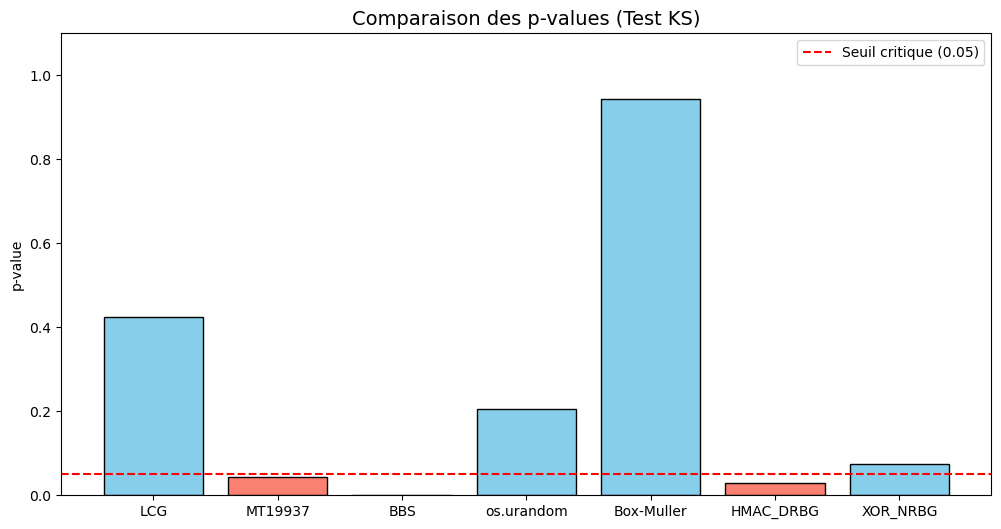

In [5]:
plt.figure(figsize=(12, 6))
colors = ['skyblue' if p > 0.05 else 'salmon' for p in df['KS (p-value)']]
plt.bar(df['Générateur'], df['KS (p-value)'], color=colors, edgecolor='black')
plt.axhline(y=0.05, color='red', linestyle='--', label='Seuil critique (0.05)')

plt.title("Comparaison des p-values (Test KS)", fontsize=14)
plt.ylabel("p-value")
plt.ylim(0, 1.1)
plt.legend()
plt.show()